In [121]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph  , START , END
from dotenv import load_dotenv
from typing import TypedDict , Literal
from math import sqrt
from pydantic import BaseModel , Field
load_dotenv()

True

In [122]:
model = ChatGoogleGenerativeAI(model = 'gemini-2.5-flash')

In [123]:
class LLMstate(TypedDict):
    blog : str
    topic : str
    response : Literal['yes' , 'no']

In [124]:
graph = StateGraph(LLMstate)

In [125]:
def gen_blog(state: LLMstate) -> LLMstate:
    topic = state['topic']
    prompt = f"This is Topic = {topic}. write a Blog on this topic"
    result = model.invoke(prompt)
    state["blog"] = result.content

    return state

In [126]:
class evalstruct(BaseModel):
    response: Literal["yes" , "no"] = Field(description = " Does The Blog need improvement ")

In [127]:
eval_llm = model.with_structured_output(evalstruct)

In [128]:
def evaluation(state: LLMstate) -> LLMstate:
    blog = state["blog"]
    prompt = f"This is my blog = \n {blog} \n. Yu are very Strict teacher tell does the blog need_improvement return yes and if the blog donmt need any improvement return  no"

    result = eval_llm.invoke(prompt)
    state["response"] = result.response

    return state





In [129]:
def condition(state: LLMstate) -> Literal["need_improvement" , END]:
    result = state["response"]
    if result == "yes":
        return "need_improvement"
    elif result == "no":
        return END

In [130]:
def need_improvement(state: LLMstate) -> LLMstate:
    blog = state["blog"]
    prompt = f"this is my bog \n {blog} \n. This need to be improved imporve this blog"
    result = model.invoke(prompt)
    state["blog"] = result.content

    return state

In [131]:
graph.add_node ("gen_blog" , gen_blog)
graph.add_node ("evaluation" , evaluation)
graph.add_node ("need_improvement" , need_improvement)

In [132]:
graph.add_edge(START , "gen_blog")
graph.add_edge("gen_blog" , "evaluation")
graph.add_conditional_edges("evaluation" , condition)
graph.add_edge("need_improvement" , "evaluation")


workflow = graph.compile()

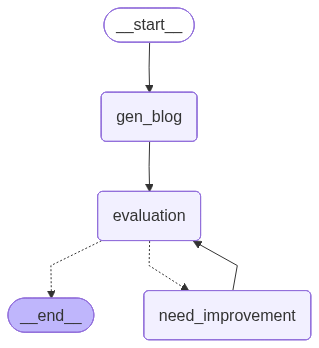

In [133]:
workflow

In [134]:
initial_state = {'topic' : 'LangGraph'}

final_state = workflow.invoke(initial_state)

In [135]:
print(final_state)

{'blog': '## LangGraph: Orchestrating Intelligent LLM Agents Beyond Simple Prompts\n\nThe world of Large Language Models (LLMs) has exploded, empowering us to build applications that can generate text, answer questions, and even write code. But as we move beyond simple, one-off prompts, a new challenge emerges: how do we build **stateful, dynamic, and truly intelligent LLM applications** that can reason, react, and adapt over multiple steps?\n\nEnter **LangGraph**.\n\nPart of the ever-evolving LangChain ecosystem, LangGraph is a powerful library designed to help you build robust and complex LLM applications by representing their logic as a **graph**. Think of it as a sophisticated GPS for your LLM, guiding it through a series of decisions and actions, remembering where it\'s been, and adapting to new information.\n\n### What is LangGraph?\n\nAt its core, LangGraph allows you to define workflows for your LLM applications using a **stateful, cyclic graph structure**. This means:\n\n1.  *